# Parte1: Detección de Bordes con OpenCV

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Cargar las imagenes y mostrar

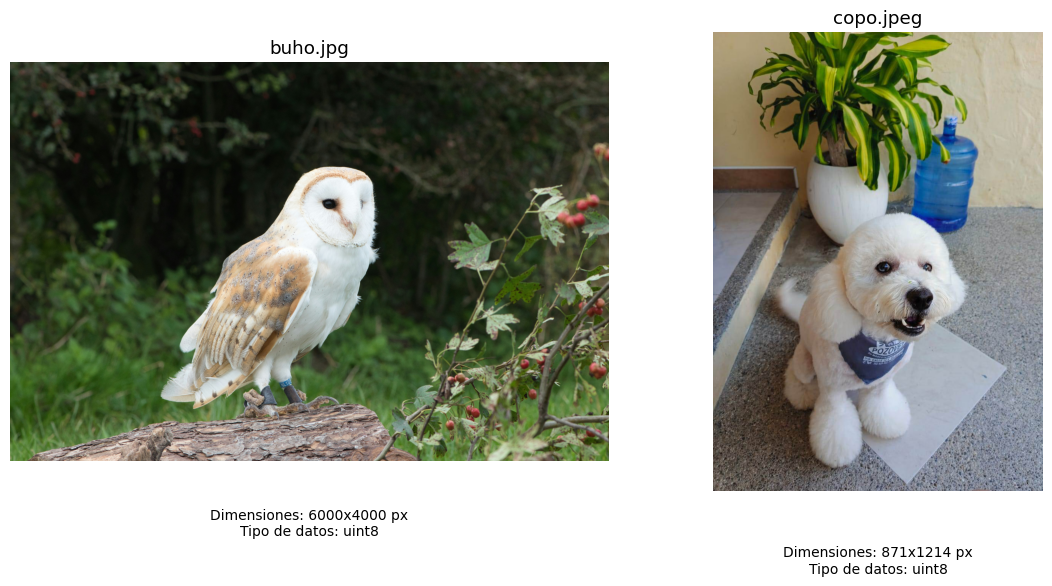

In [ ]:
data_folder = Path("../data")

# Verificar que la carpeta existe
if not data_folder.exists():
    print(f"Error: La carpeta '{data_folder}' no existe")
    print(f"Ruta buscada: {data_folder.absolute()}")
else:
    archivos = ["buho.jpg", "copo.jpeg"]
    imagenes_cargadas = []

    # Crear figura con 1 fila y 2 columnas
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    for ax, archivo in zip(axes, archivos):
        ruta_img = data_folder / archivo

        if not ruta_img.exists():
            print(f"No se encontró la imagen: {archivo}")
            ax.set_title(f"{archivo}\nNo encontrada")
            ax.axis("off")
            continue

        # Cargar imagen
        img = cv2.imread(str(ruta_img))

        if img is None:
            print(f"No se pudo cargar la imagen: {archivo}")
            ax.set_title(f"{archivo}\nError al cargar")
            ax.axis("off")
            continue
        
        # Cargar las imagenes en una 
        imagenes_cargadas.append(img)

        # Convertir BGR → RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Mostrar imagen
        ax.imshow(img_rgb)
        ax.axis("off")

        # Información de la imagen
        ax.set_title(archivo)

        info = f"Dimensiones: {img.shape[1]}x{img.shape[0]} px\nTipo de datos: {img.dtype}"

        ax.text(0.5, -0.12, info, ha='center', va='top', transform=ax.transAxes, fontsize=10)

    plt.tight_layout()
    plt.show()


## Mostrar las imágenes en escala de grises

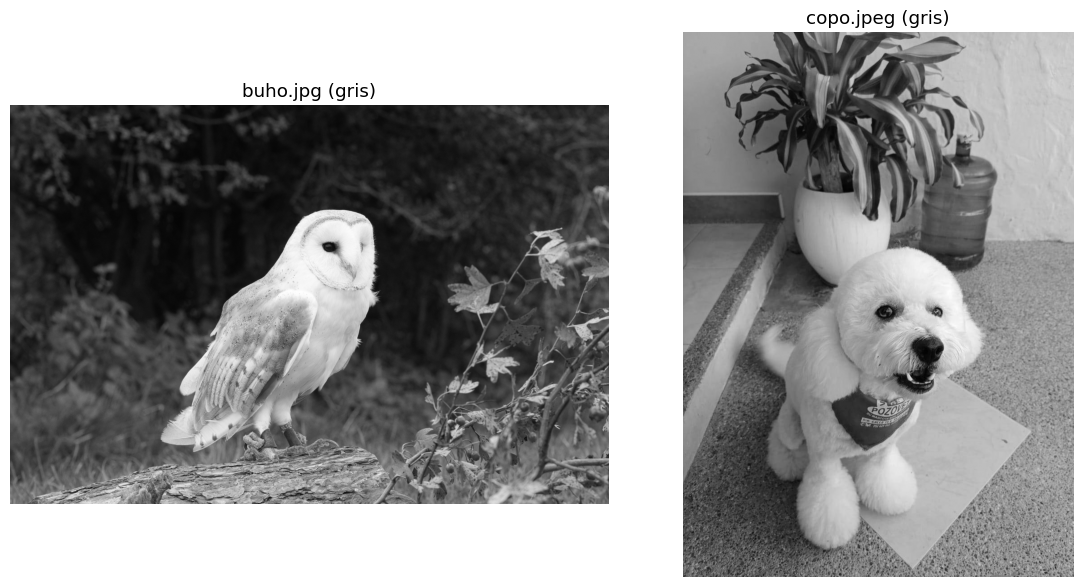

In [ ]:
fig, axes = plt.subplots(1, len(imagenes_cargadas), figsize=(12, 6))

for ax, img, nombre in zip(axes, imagenes_cargadas, archivos):
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ax.imshow(gris, cmap='gray')
    ax.axis("off")
    ax.set_title(f"{nombre} (gris)")

plt.tight_layout()
plt.show()


## Aplicamos el filtro Canny

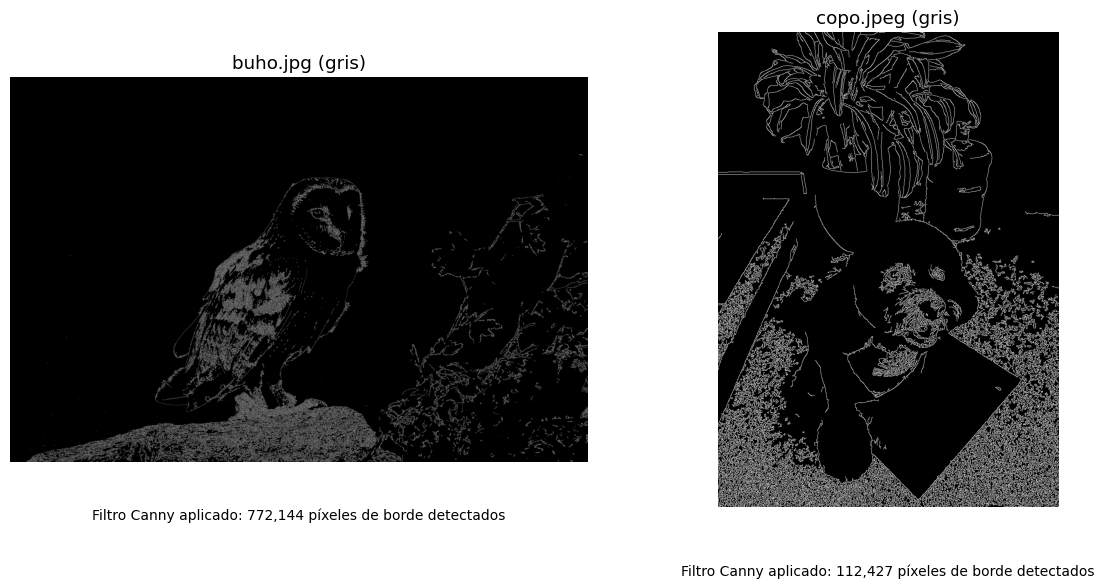

In [ ]:
threshold1 = 50   # Umbral bajo
threshold2 = 150  # Umbral alto (debe ser 2-3x el umbral bajo)

fig, axes = plt.subplots(1, len(imagenes_cargadas), figsize=(12, 6))

for ax, img, nombre in zip(axes, imagenes_cargadas, archivos):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges_canny = cv2.Canny(img_gris, threshold1, threshold2)
    ax.imshow(edges_canny, cmap='gray')
    ax.axis("off")
    ax.set_title(f"{nombre} (gris)")

    info = f"Filtro Canny aplicado: {np.sum(edges_canny > 0):,} píxeles de borde detectados"

    ax.text(0.5, -0.12, info, ha='center', va='top', transform=ax.transAxes, fontsize=10)

plt.tight_layout()
plt.show()

### Comparativo de la imagen original, imagen gris y filtro Canny

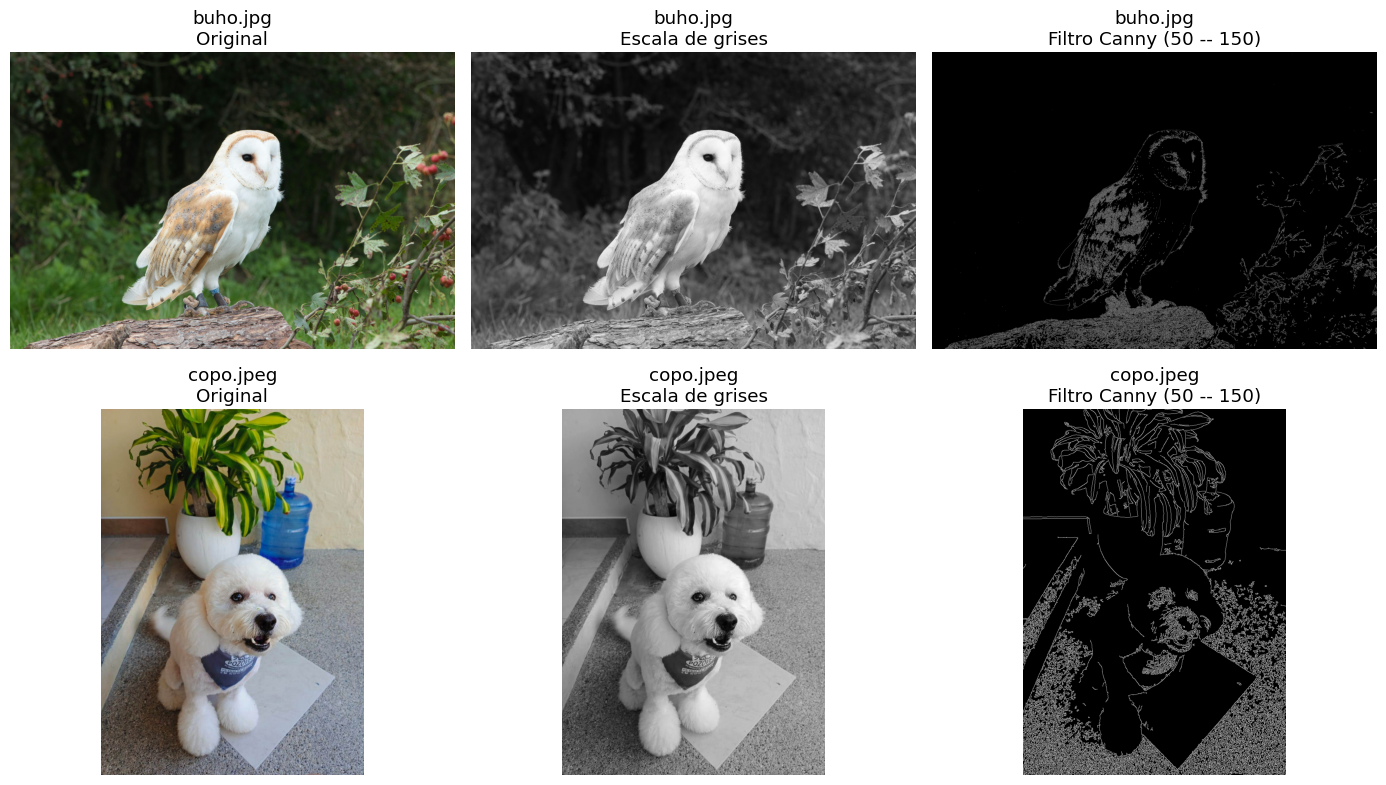

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for fila, (img, nombre) in enumerate(zip(imagenes_cargadas, archivos)):

    # --- 1) Imagen original ---
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[fila, 0].imshow(img_rgb)
    axes[fila, 0].axis("off")
    axes[fila, 0].set_title(f"{nombre}\nOriginal")

    # --- 2) Escala de grises ---
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    axes[fila, 1].imshow(img_gris, cmap='gray')
    axes[fila, 1].axis("off")
    axes[fila, 1].set_title(f"{nombre}\nEscala de grises")

    # --- 3) Filtro Canny ---
    edges_canny = cv2.Canny(img_gris, threshold1, threshold2)
    axes[fila, 2].imshow(edges_canny, cmap='gray')
    axes[fila, 2].axis("off")
    axes[fila, 2].set_title(f"{nombre}\nFiltro Canny ({threshold1} -- {threshold2})")

plt.tight_layout()
plt.show()

## Aplicar filtro Sobel a la imagen original y al resultado del filtro Canny

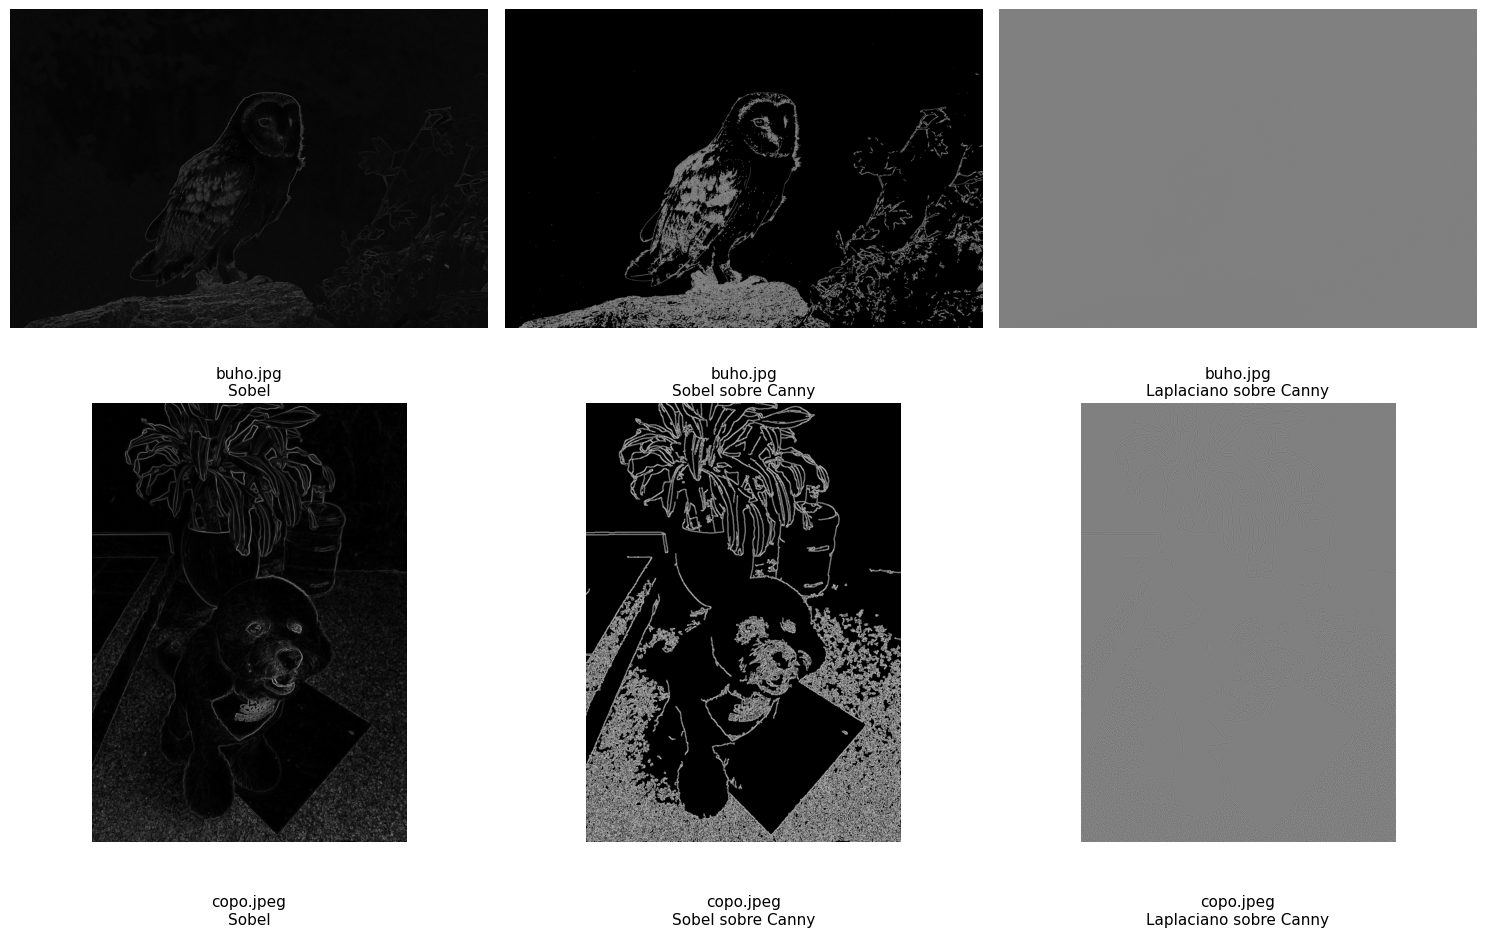

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for fila, (img, nombre) in enumerate(zip(imagenes_cargadas, archivos)):

    # Convertir a gris
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Sobel directo ---
    sobelx = cv2.Sobel(gris, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gris, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobelx, sobely)

    axes[fila, 0].imshow(sobel_mag, cmap='gray')
    axes[fila, 0].axis("off")
    axes[fila, 0].text(0.5, -0.12,
                       f"{nombre}\nSobel",
                       ha='center', va='top',
                       transform=axes[fila, 0].transAxes)

    # --- 2) Sobel sobre Canny ---
    canny = cv2.Canny(gris, threshold1, threshold2)
    sobel_canny_x = cv2.Sobel(canny, cv2.CV_64F, 1, 0, ksize=3)
    sobel_canny_y = cv2.Sobel(canny, cv2.CV_64F, 0, 1, ksize=3)
    sobel_canny_mag = cv2.magnitude(sobel_canny_x, sobel_canny_y)

    axes[fila, 1].imshow(sobel_canny_mag, cmap='gray')
    axes[fila, 1].axis("off")
    axes[fila, 1].text(0.5, -0.12,
                       f"{nombre}\nSobel sobre Canny",
                       ha='center', va='top',
                       transform=axes[fila, 1].transAxes)

    # --- 3) Otro filtro sobre Canny (Laplaciano) ---
    laplaciano = cv2.Laplacian(canny, cv2.CV_64F)

    axes[fila, 2].imshow(laplaciano, cmap='gray')
    axes[fila, 2].axis("off")
    axes[fila, 2].text(0.5, -0.12,
                       f"{nombre}\nLaplaciano sobre Canny",
                       ha='center', va='top',
                       transform=axes[fila, 2].transAxes)

plt.tight_layout()
plt.show()

### Comentario

En la imagen anterior al aplicar el filtro laplacianos sobre la imagen con el filyro Canny, no muestra practicamente nada, al ojo humano, debido a que no hay gradientes en la imagen, las zonas negras son planas (0), las zonas blancas son planas (255), por lo que no se encuentra variación


## Conclusiones

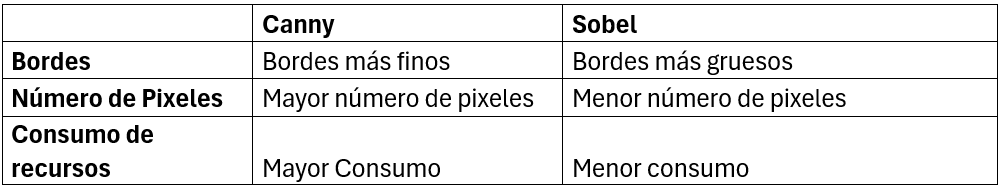

Filtro Sobel es útil cuando se busca obtener formas generales, contornos gruesos o características estructurales de un objeto, segmentación rápida, detección de regiones. Es rápido, ligero y suficiente para tareas donde la precisión no es crítica.

Filtro Canny es ideal cuando se requiere precisión, bordes finos y detección robusta. Es especialmente valioso en sistemas autónomos, visión industrial y detección de objetos deformes o irregulares.

En nuestro ejemplo el filtro sobel sobre canny, resalta aun mas los bordes, mejorando su calidad.
